# Amazon Mattress Price 분석 : Top 4 Brand

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-5213911f50a5.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [45]:
# get the data from BigQuery
sql = f"""
select * from tmp.stck_zns_comp_sales_anal
"""

df = bqclient.query(sql).to_dataframe()

In [47]:
print(df)

             asin               sku    brand yr_month  \
0      B0CYGSNYNW              None  EGOHOME  2025-11   
1      B0CYGSNYNW              None  EGOHOME  2025-12   
2      B0CYGSNYNW              None  EGOHOME  2026-02   
3      B0CYGSNYNW              None  EGOHOME  2026-01   
4      B0DXVVNTQQ              None  EGOHOME  2025-03   
...           ...               ...      ...      ...   
11162  B09NB8LG5P  ‎N-M02020-12-Q-C  NOVILLA  2025-02   
11163  B09NB8LG5P  ‎N-M02020-12-Q-C  NOVILLA  2025-01   
11164  B09NB8LG5P  ‎N-M02020-12-Q-C  NOVILLA  2025-07   
11165  B09NB8LG5P  ‎N-M02020-12-Q-C  NOVILLA  2025-06   
11166  B09NB8LG5P  ‎N-M02020-12-Q-C  NOVILLA  2025-03   

                                                   title  yr_month_sales_rank  \
0      egohome 12 inch queen mattress, cool memory fo...                  417   
1      egohome 12 inch queen mattress, cool memory fo...                  390   
2      egohome 12 inch queen mattress, cool memory fo...                

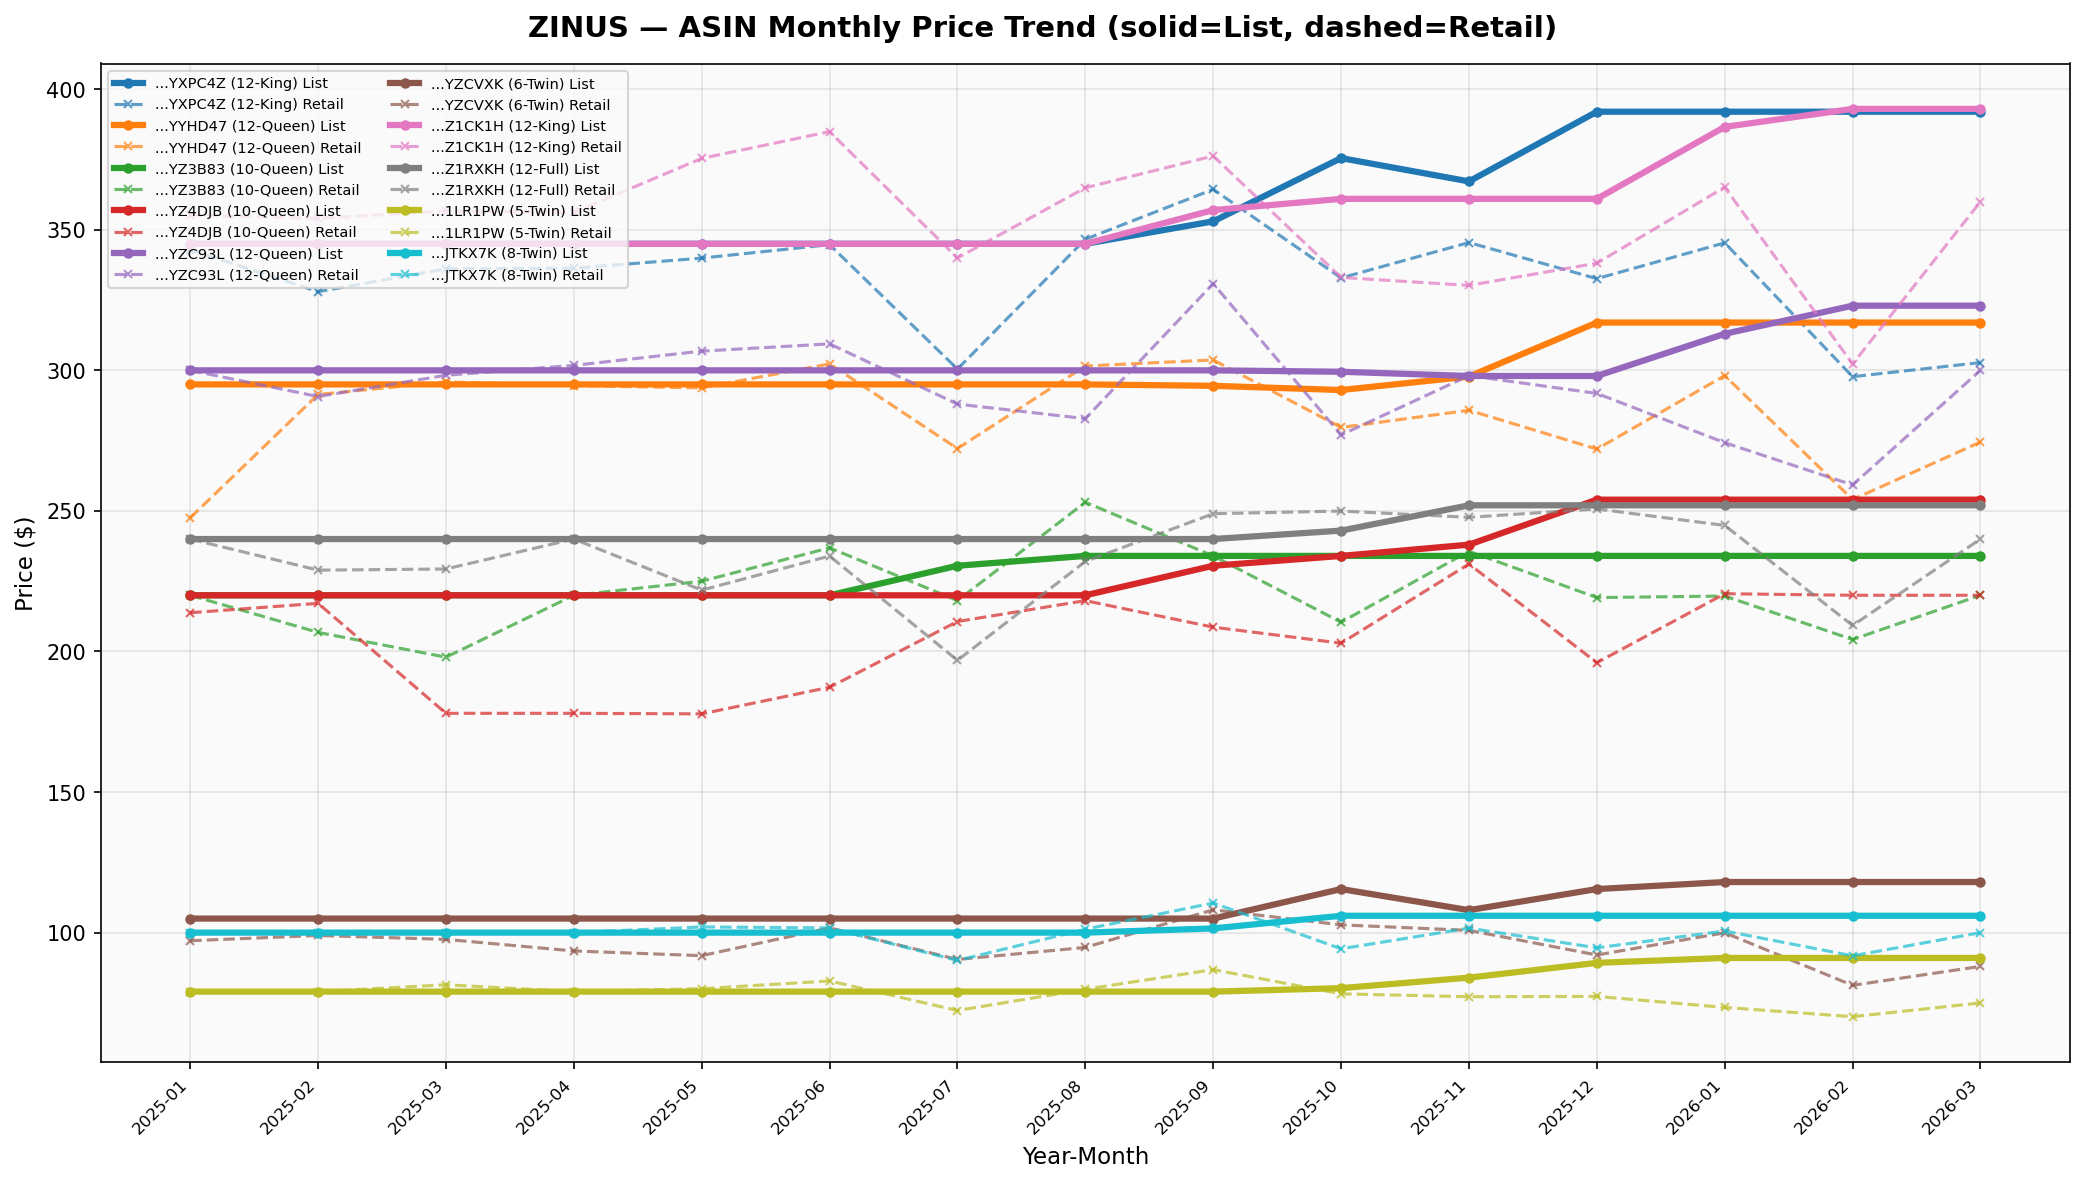

✅ Saved: chart_price_zinus.png


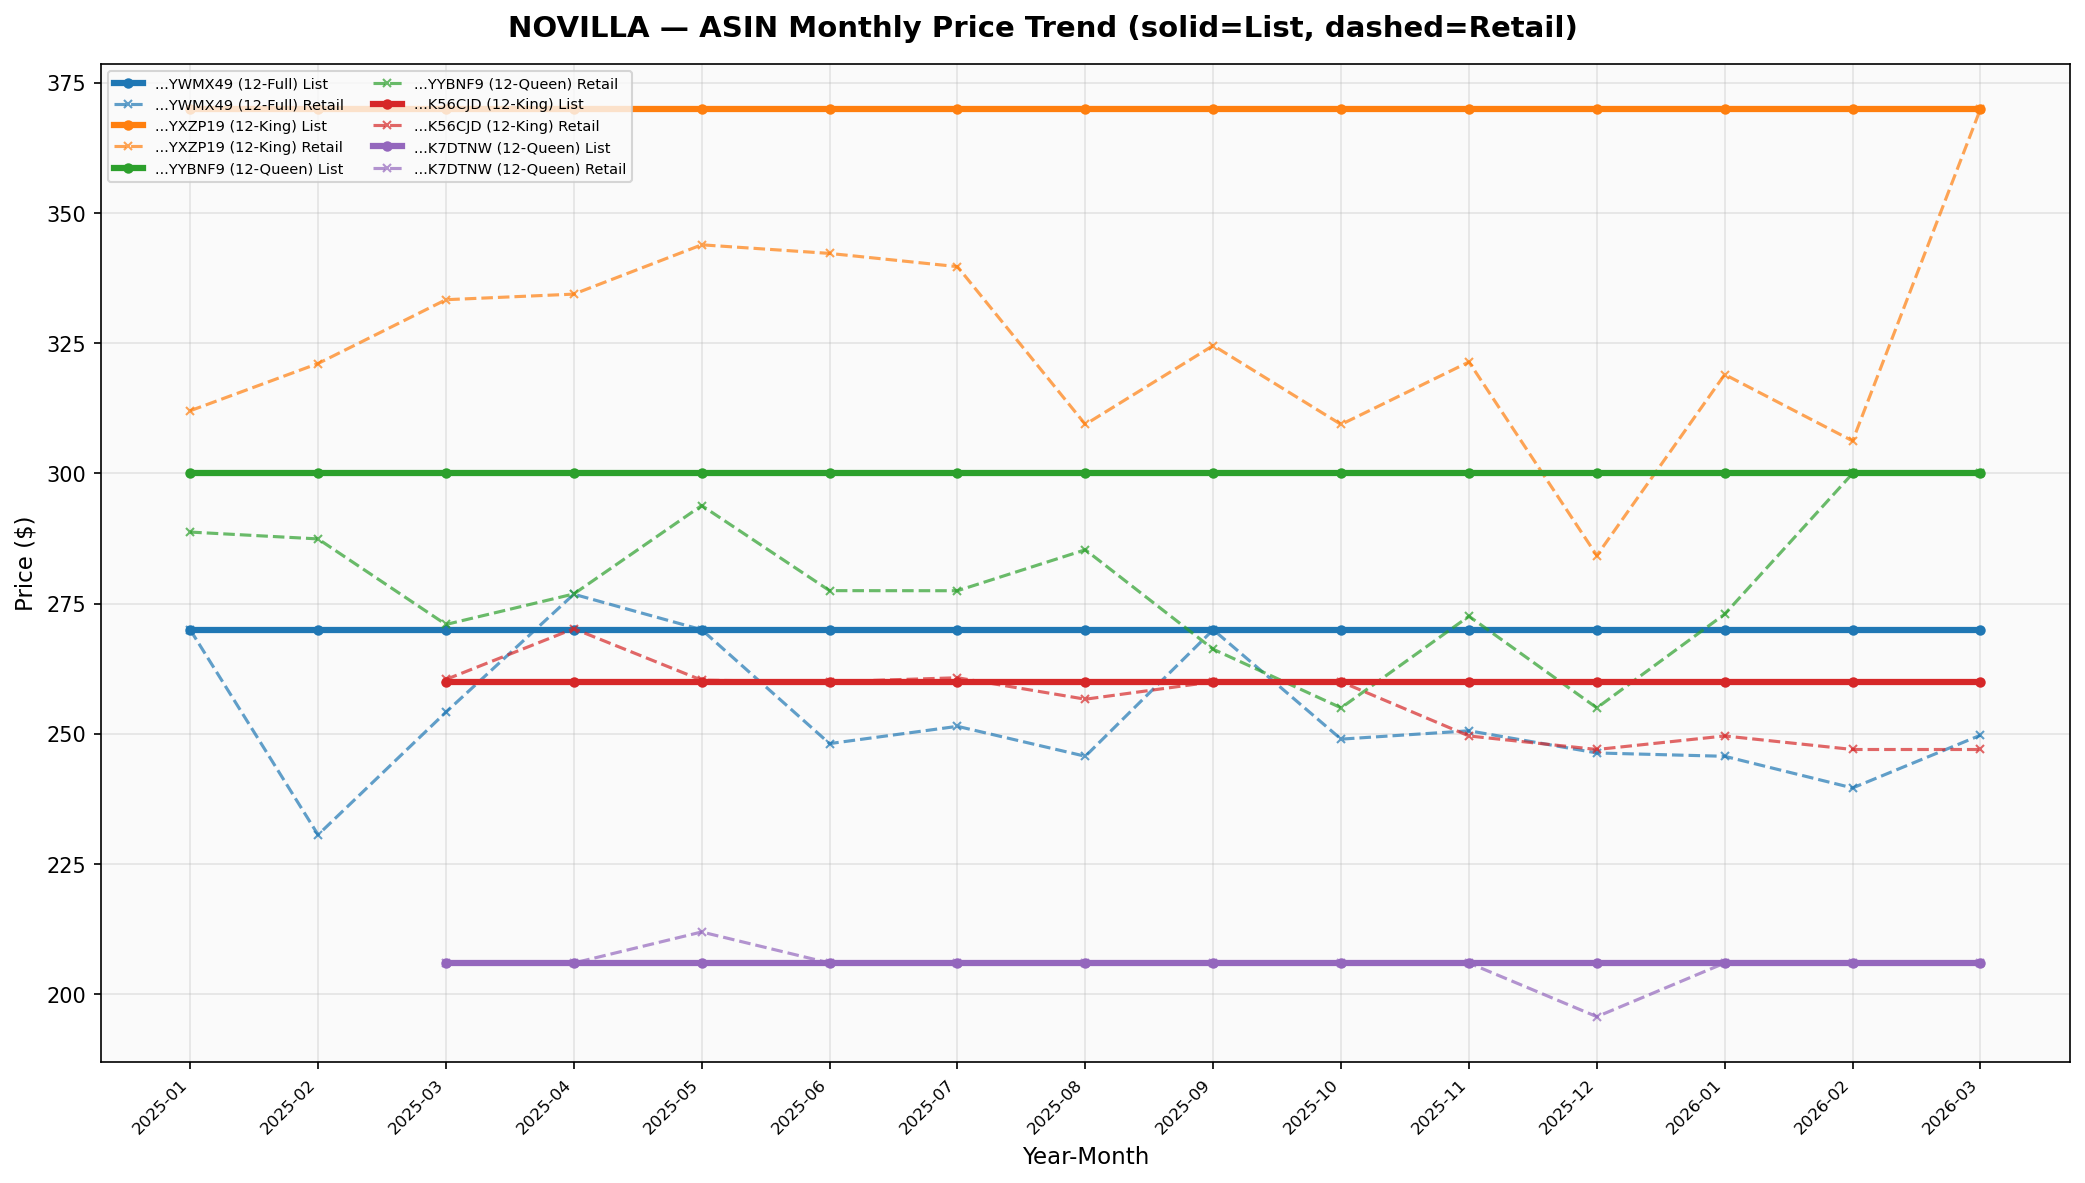

✅ Saved: chart_price_novilla.png


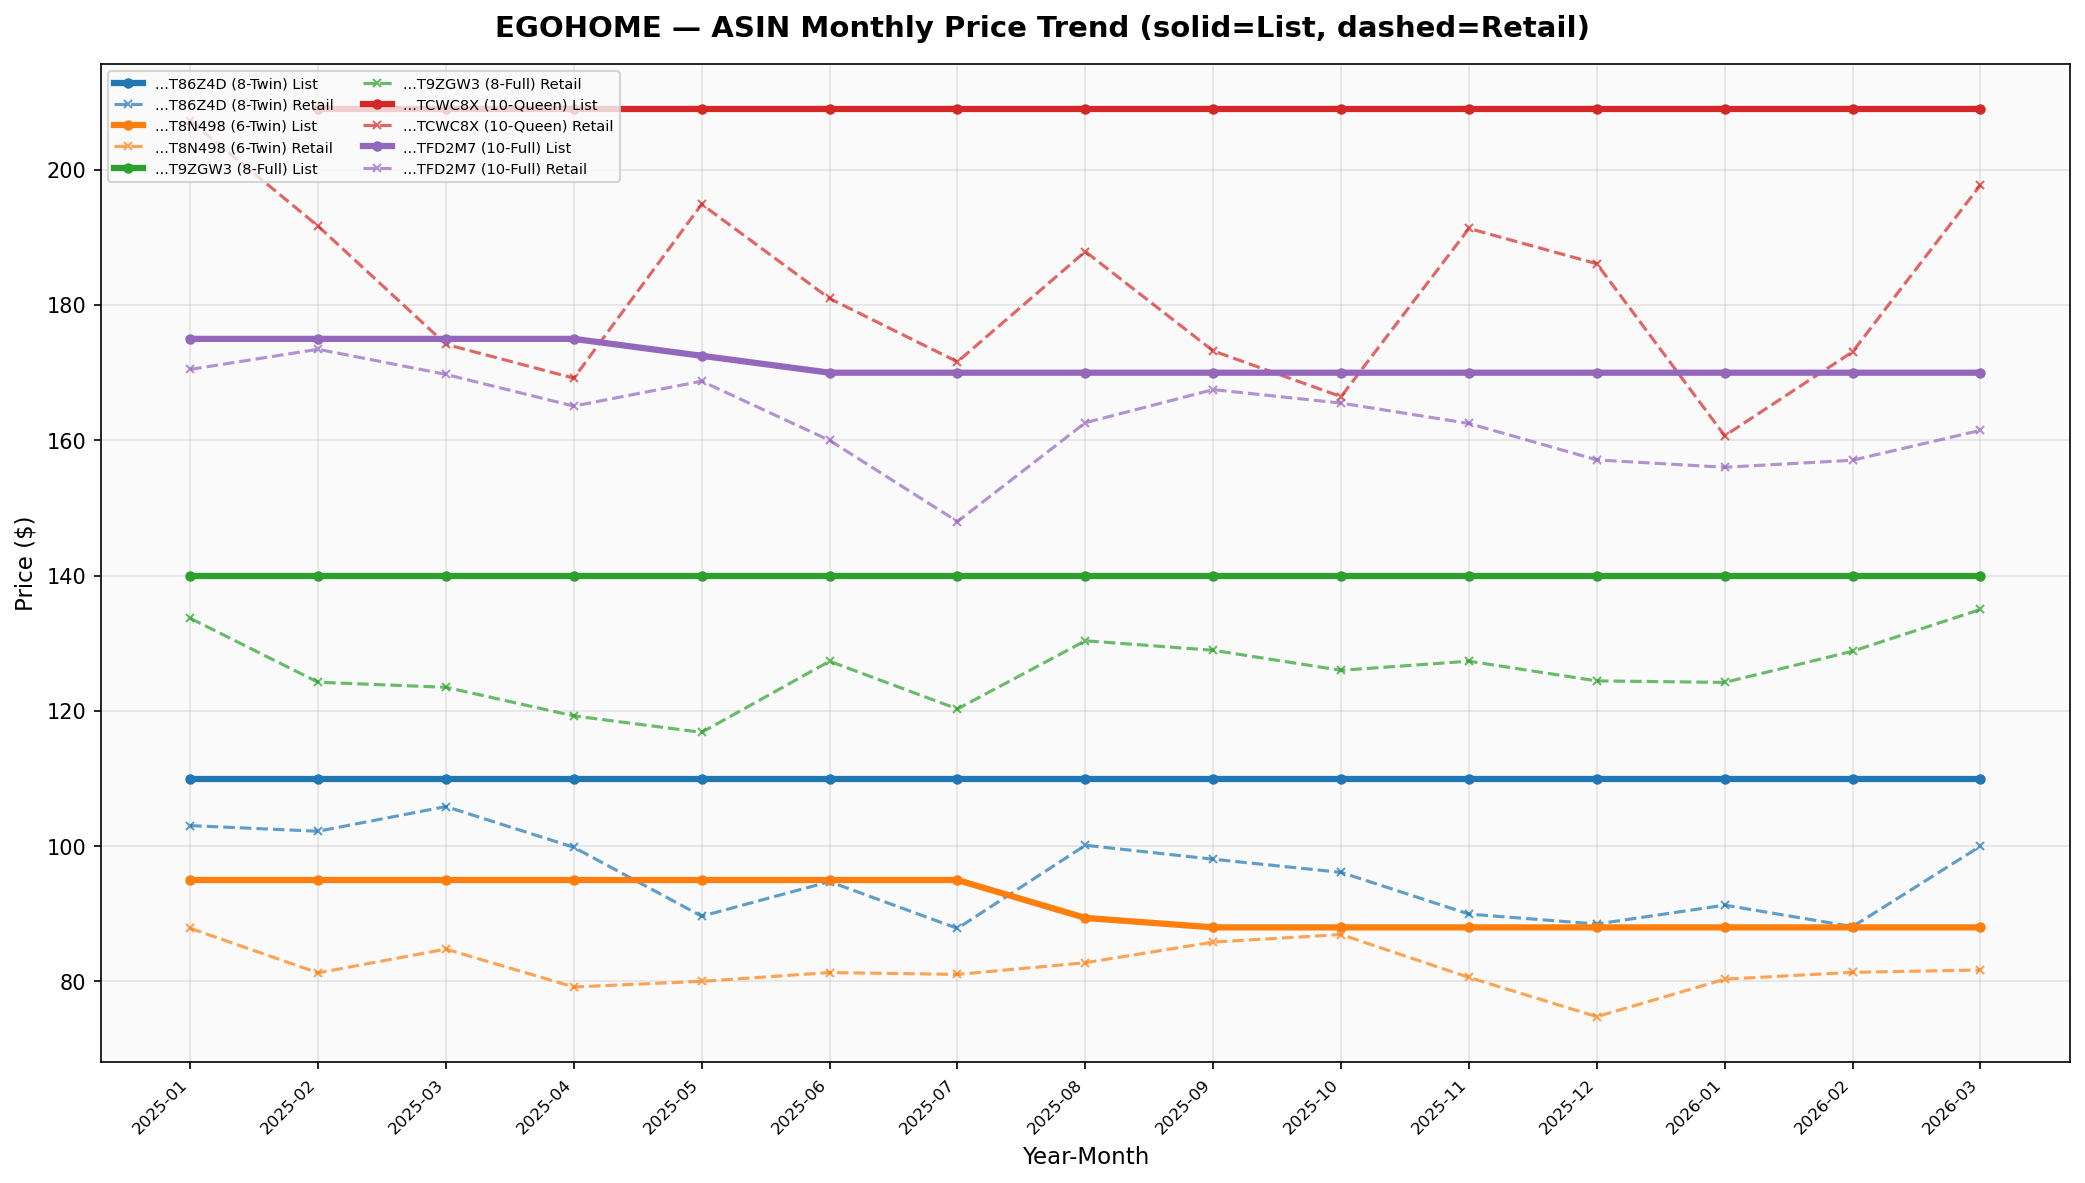

✅ Saved: chart_price_egohome.png


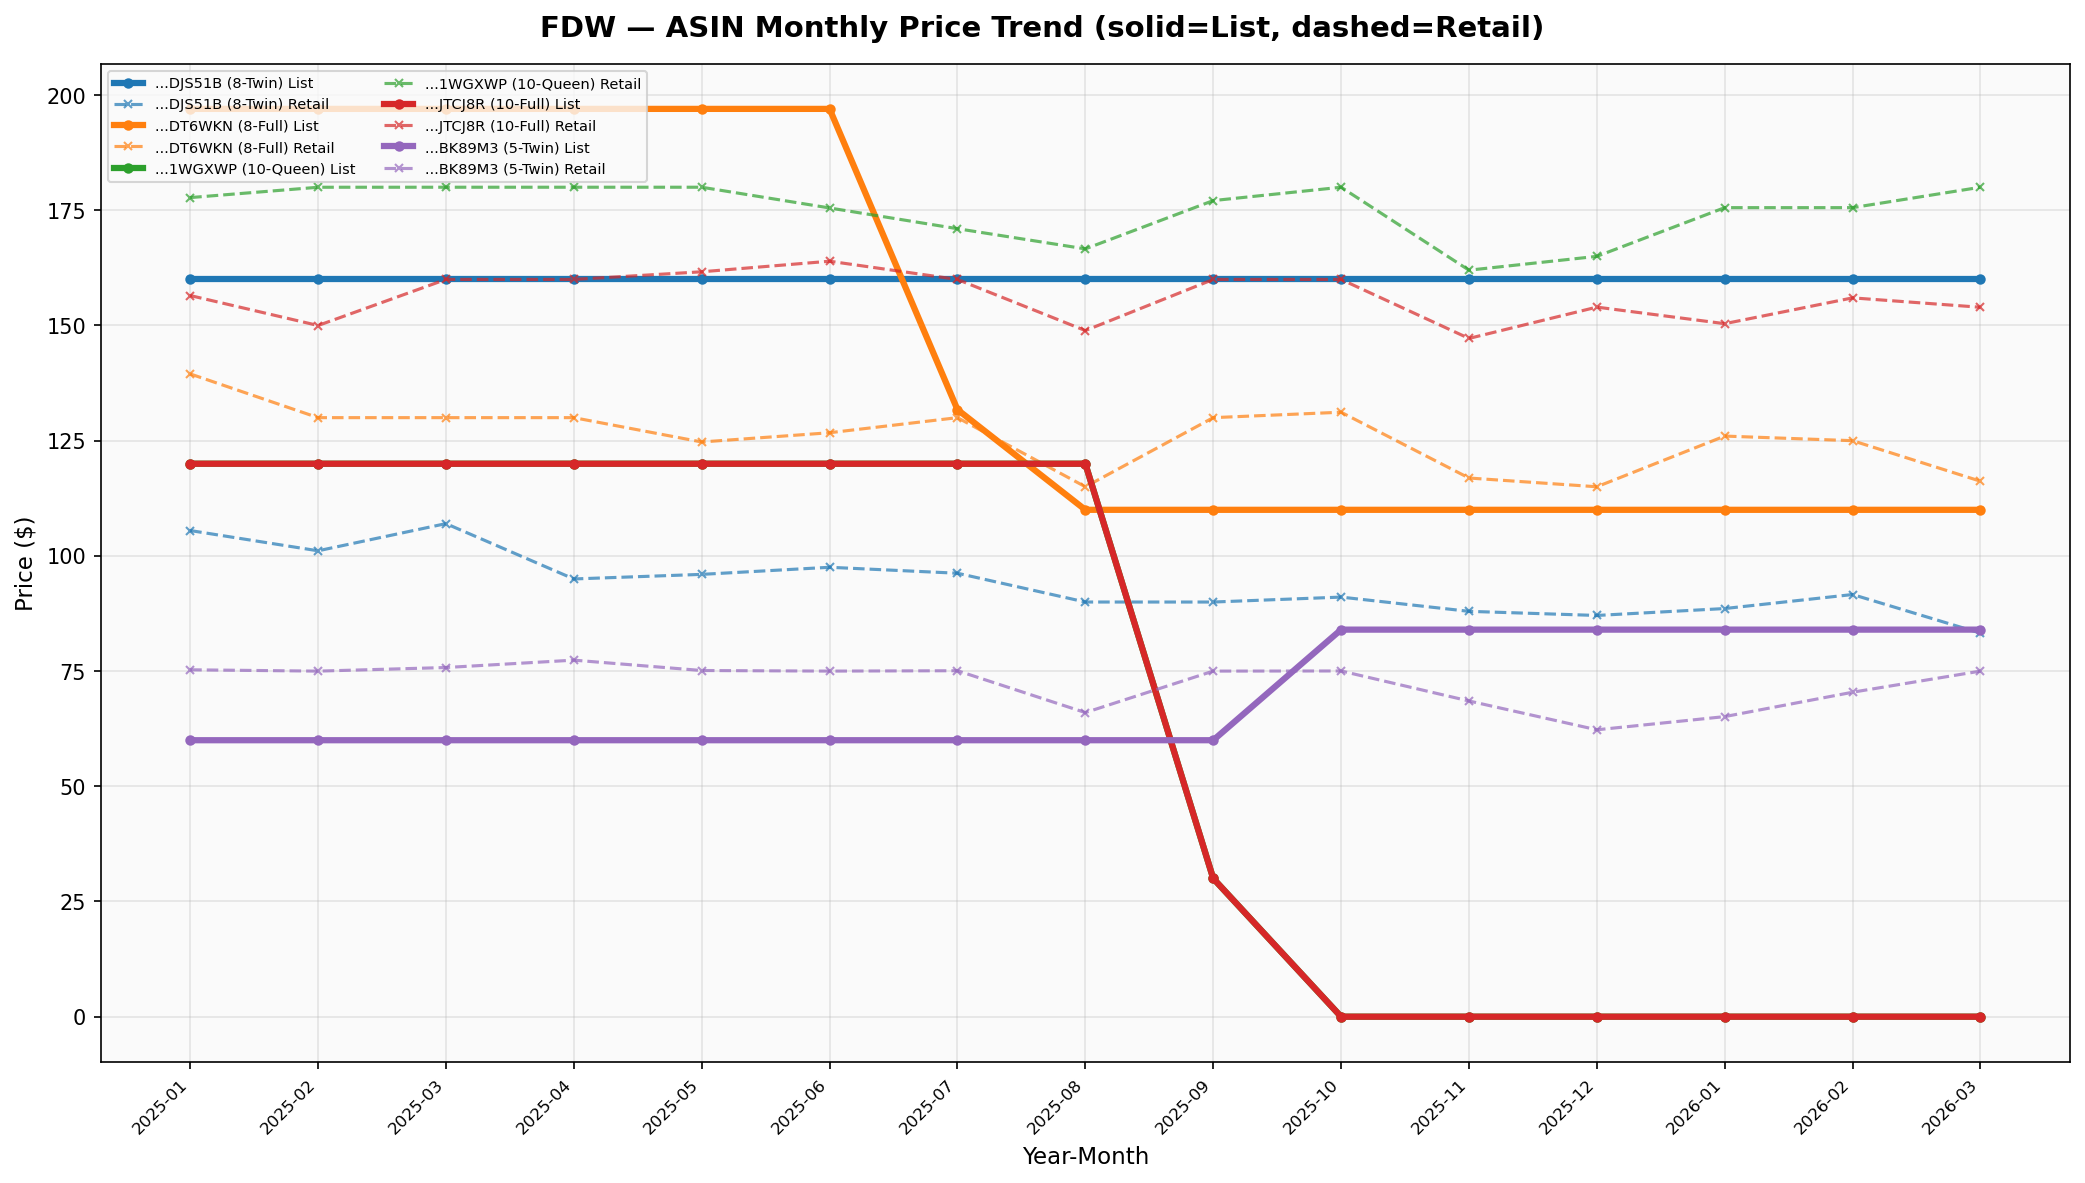

✅ Saved: chart_price_fdw.png


In [53]:
target = [
    ('EGOHOME','B0DKT9ZGW3'), ('EGOHOME','B0DKT86Z4D'), ('EGOHOME','B0DKT8N498'),
    ('EGOHOME','B0DKTCWC8X'), ('EGOHOME','B0DKTFD2M7'),
    ('FDW','B08YDJS51B'), ('FDW','B09Y1WGXWP'), ('FDW','B08YDT6WKN'),
    ('FDW','B0B2JTCJ8R'), ('FDW','B0C1BK89M3'),
    ('NOVILLA','B083YYBNF9'), ('NOVILLA','B083YXZP19'), ('NOVILLA','B083YWMX49'),
    ('NOVILLA','B0DWK56CJD'), ('NOVILLA','B0DWK7DTNW'),
    ('ZINUS','B0CKZ1CK1H'), ('ZINUS','B0CKYZ3B83'), ('ZINUS','B0CKYZC93L'),
    ('ZINUS','B0CSJTKX7K'), ('ZINUS','B0CP1LR1PW'), ('ZINUS','B0CKYZCVXK'),
    ('ZINUS','B0CKYYHD47'), ('ZINUS','B0CKZ1RXKH'), ('ZINUS','B0CKYXPC4Z'),
    ('ZINUS','B0CKYZ4DJB'),
]
cte = df[df.set_index(['brand','asin']).index.isin(target)].copy()
cte['segment'] = cte['inch'].astype(str) + '-' + cte['size'].astype(str)
all_months = sorted(cte['yr_month'].unique())
brands = ['ZINUS', 'NOVILLA', 'EGOHOME', 'FDW']

for brand in brands:
    bdf = cte[cte['brand'] == brand]
    asins = sorted(bdf['asin'].unique())
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.suptitle(f'{brand} — ASIN Monthly Price Trend (solid=List, dashed=Retail)',
                 fontsize=14, fontweight='bold')
    for asin in asins:
        adf = bdf[bdf['asin'] == asin].sort_values('yr_month')
        seg = adf['segment'].iloc[0] if len(adf) > 0 else ''
        label = f"...{asin[-6:]} ({seg})"
        x_pos = [all_months.index(m) for m in adf['yr_month']]
        line = ax.plot(x_pos, adf['avg_list_price'],
                       marker='o', markersize=4, linewidth=3, label=f"{label} List")
        color = line[0].get_color()
        ax.plot(x_pos, adf['avg_retail_price'],
                marker='x', markersize=4, linewidth=1.5, linestyle='--',
                color=color, alpha=0.7, label=f"{label} Retail")
    ax.set_xticks(range(len(all_months)))
    ax.set_xticklabels(all_months, fontsize=8, rotation=45, ha='right')
    ax.set_ylabel('Price ($)', fontsize=11)
    ax.set_xlabel('Year-Month', fontsize=11)
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    plt.tight_layout()
    plt.show()
    plt.savefig(f'chart_price_{brand.lower()}.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: chart_price_{brand.lower()}.png")

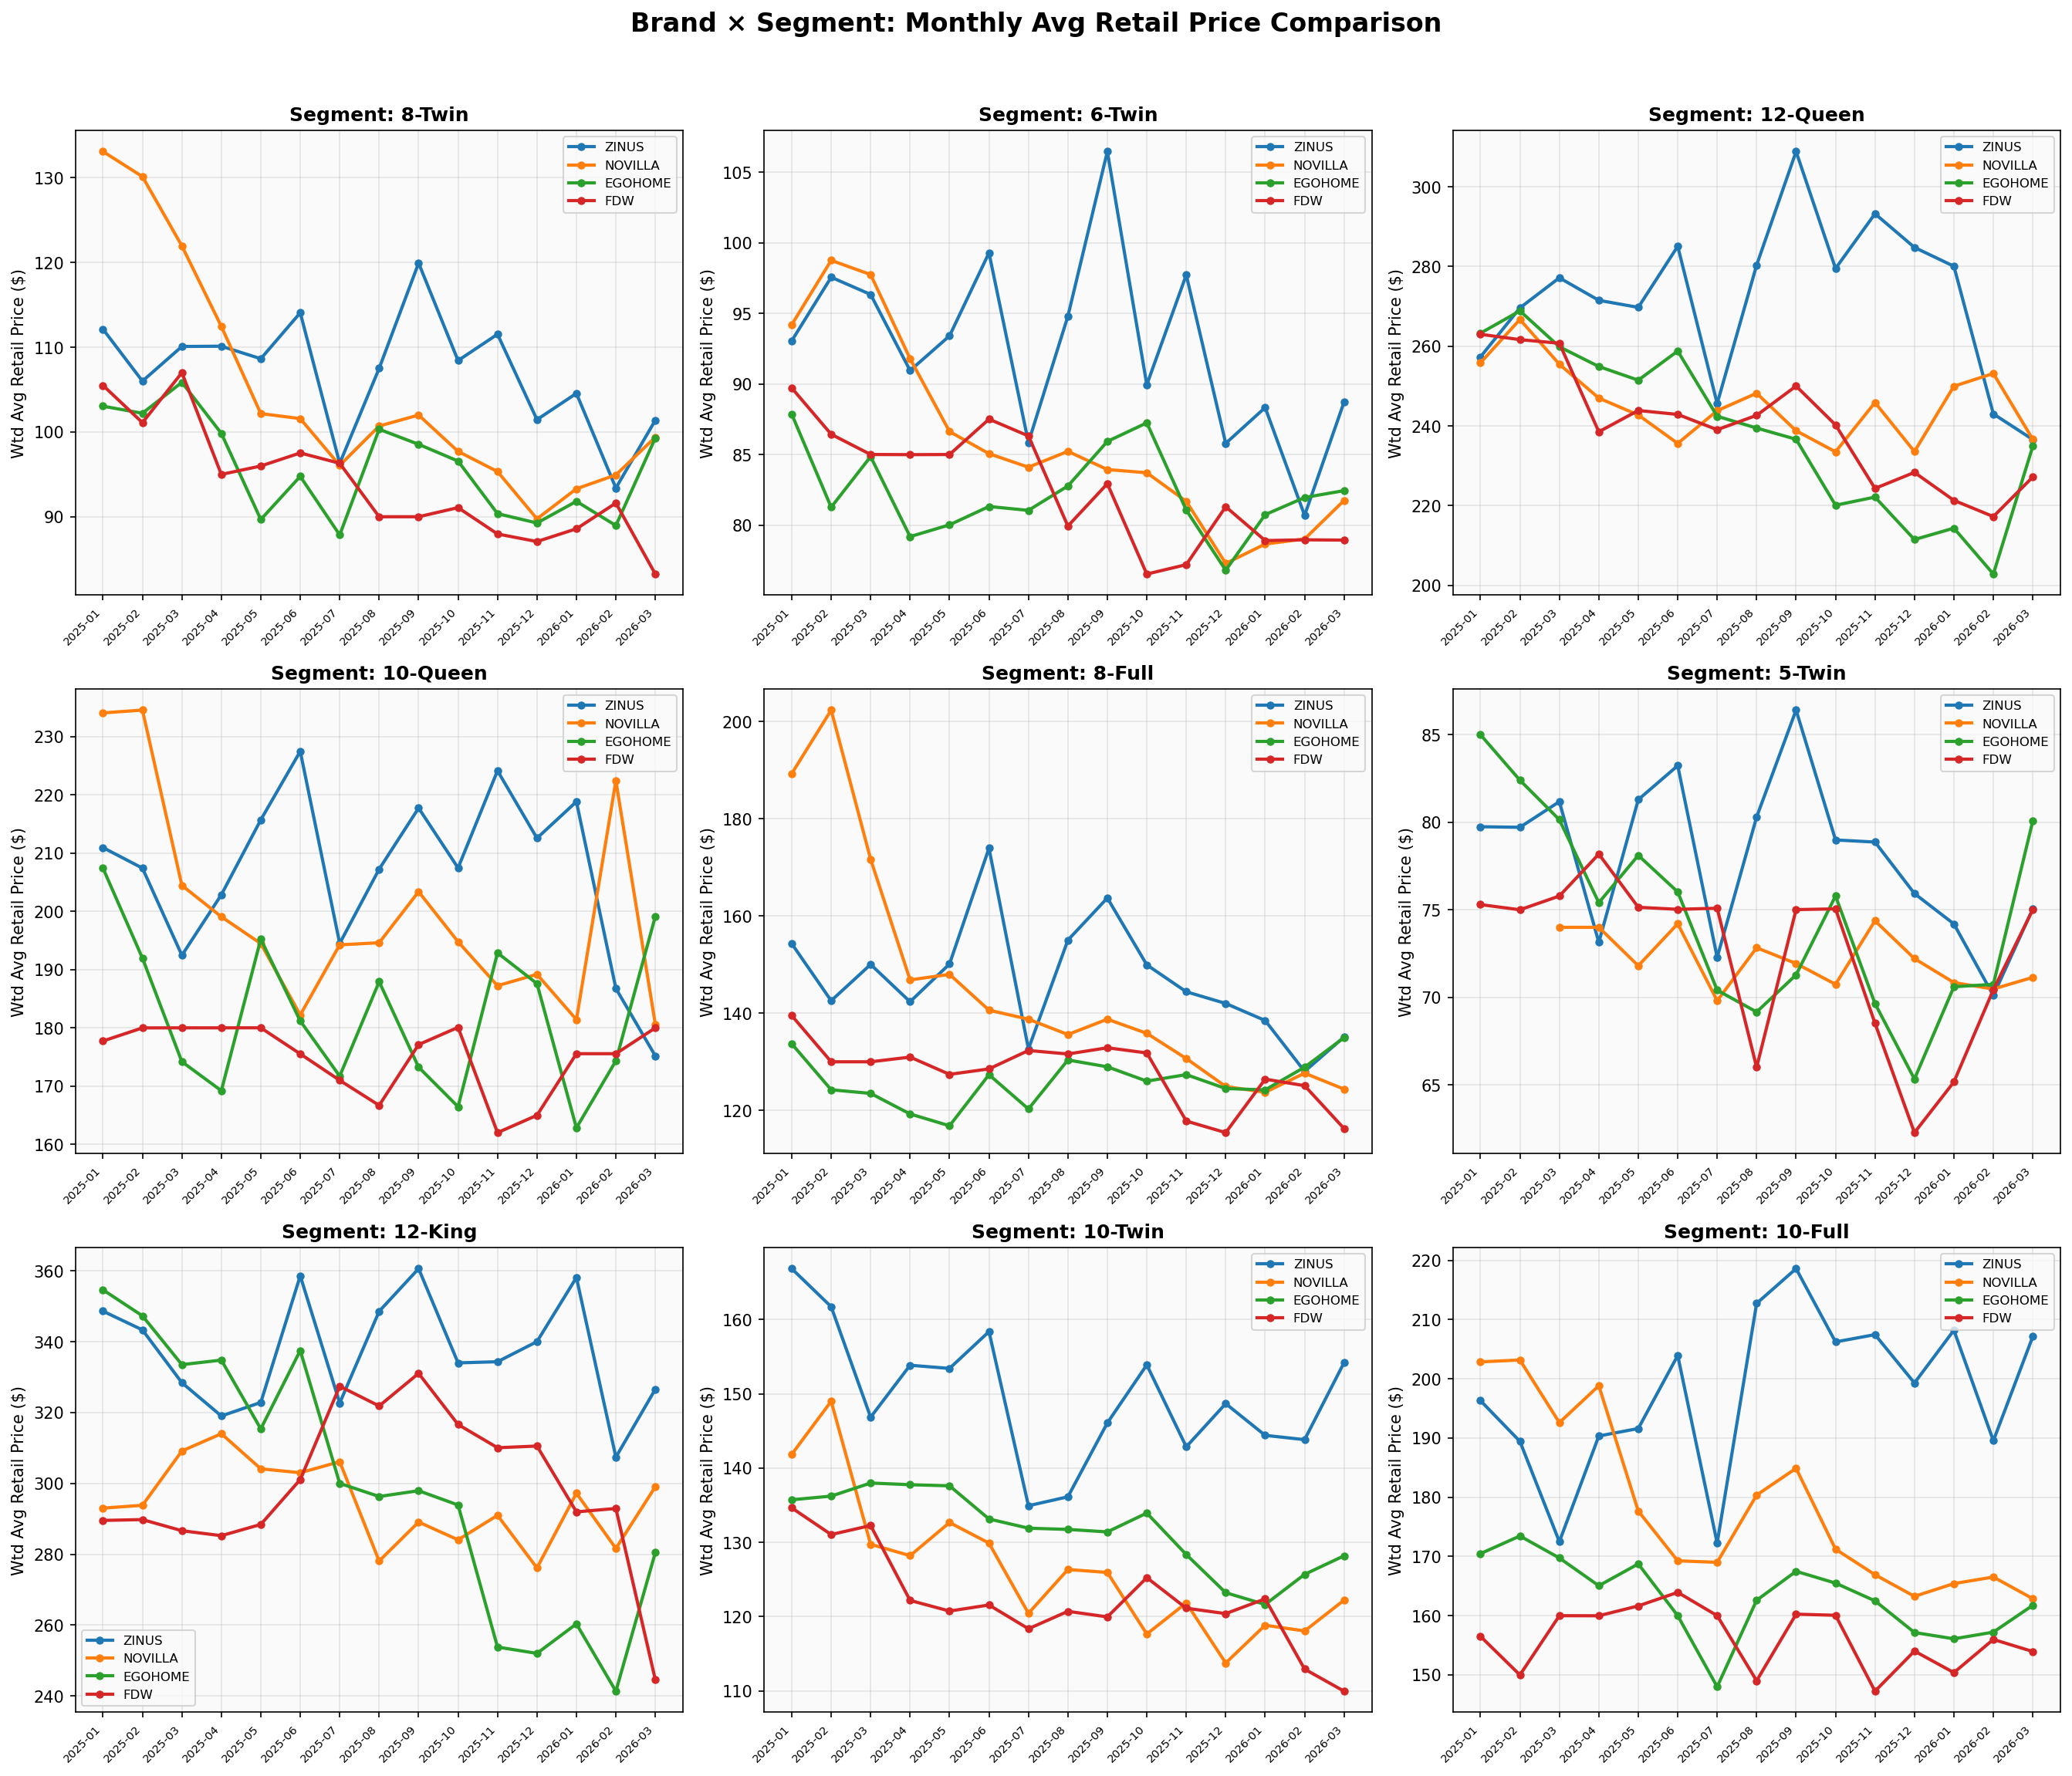

In [55]:
# ── 대상 데이터 필터 ──
brands = ['ZINUS', 'NOVILLA', 'EGOHOME', 'FDW']
brand_colors = {'ZINUS': '#1f77b4', 'NOVILLA': '#ff7f0e', 'EGOHOME': '#2ca02c', 'FDW': '#d62728'}

bdf = df[df['brand'].isin(brands)].copy()
bdf['segment'] = bdf['inch'].astype(str) + '-' + bdf['size'].astype(str)

# ── 주요 세그먼트 선정 (총 유닛 기준 Top 9) ──
top_segments = bdf.groupby('segment')['units'].sum().nlargest(9).index.tolist()

all_months = sorted(bdf['yr_month'].unique())

# ── 세그먼트별 차트 (3×3 그리드) ──
n_cols = 3
n_rows = (len(top_segments) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Brand × Segment: Monthly Avg Retail Price Comparison',
             fontsize=16, fontweight='bold', y=1.02)

for idx, seg in enumerate(top_segments):
    ax = axes[idx // n_cols, idx % n_cols]
    sdf = bdf[bdf['segment'] == seg]

    for brand in brands:
        bsdf = sdf[sdf['brand'] == brand]
        if len(bsdf) == 0:
            continue
        monthly = (bsdf.groupby('yr_month')
                   .apply(lambda g: np.average(g['avg_retail_price'], weights=g['units'])
                          if g['units'].sum() > 0 else np.nan)
                   .dropna())
        months = sorted(monthly.index)
        x_pos = [all_months.index(m) for m in months]
        ax.plot(x_pos, [monthly[m] for m in months],
                marker='o', markersize=4, linewidth=2,
                color=brand_colors[brand], label=brand)

    ax.set_xticks(range(len(all_months)))
    ax.set_xticklabels(all_months, fontsize=7, rotation=45, ha='right')
    ax.set_title(f'Segment: {seg}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Wtd Avg Retail Price ($)')
    ax.legend(fontsize=8)

# 빈 subplot 숨기기
for idx in range(len(top_segments), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

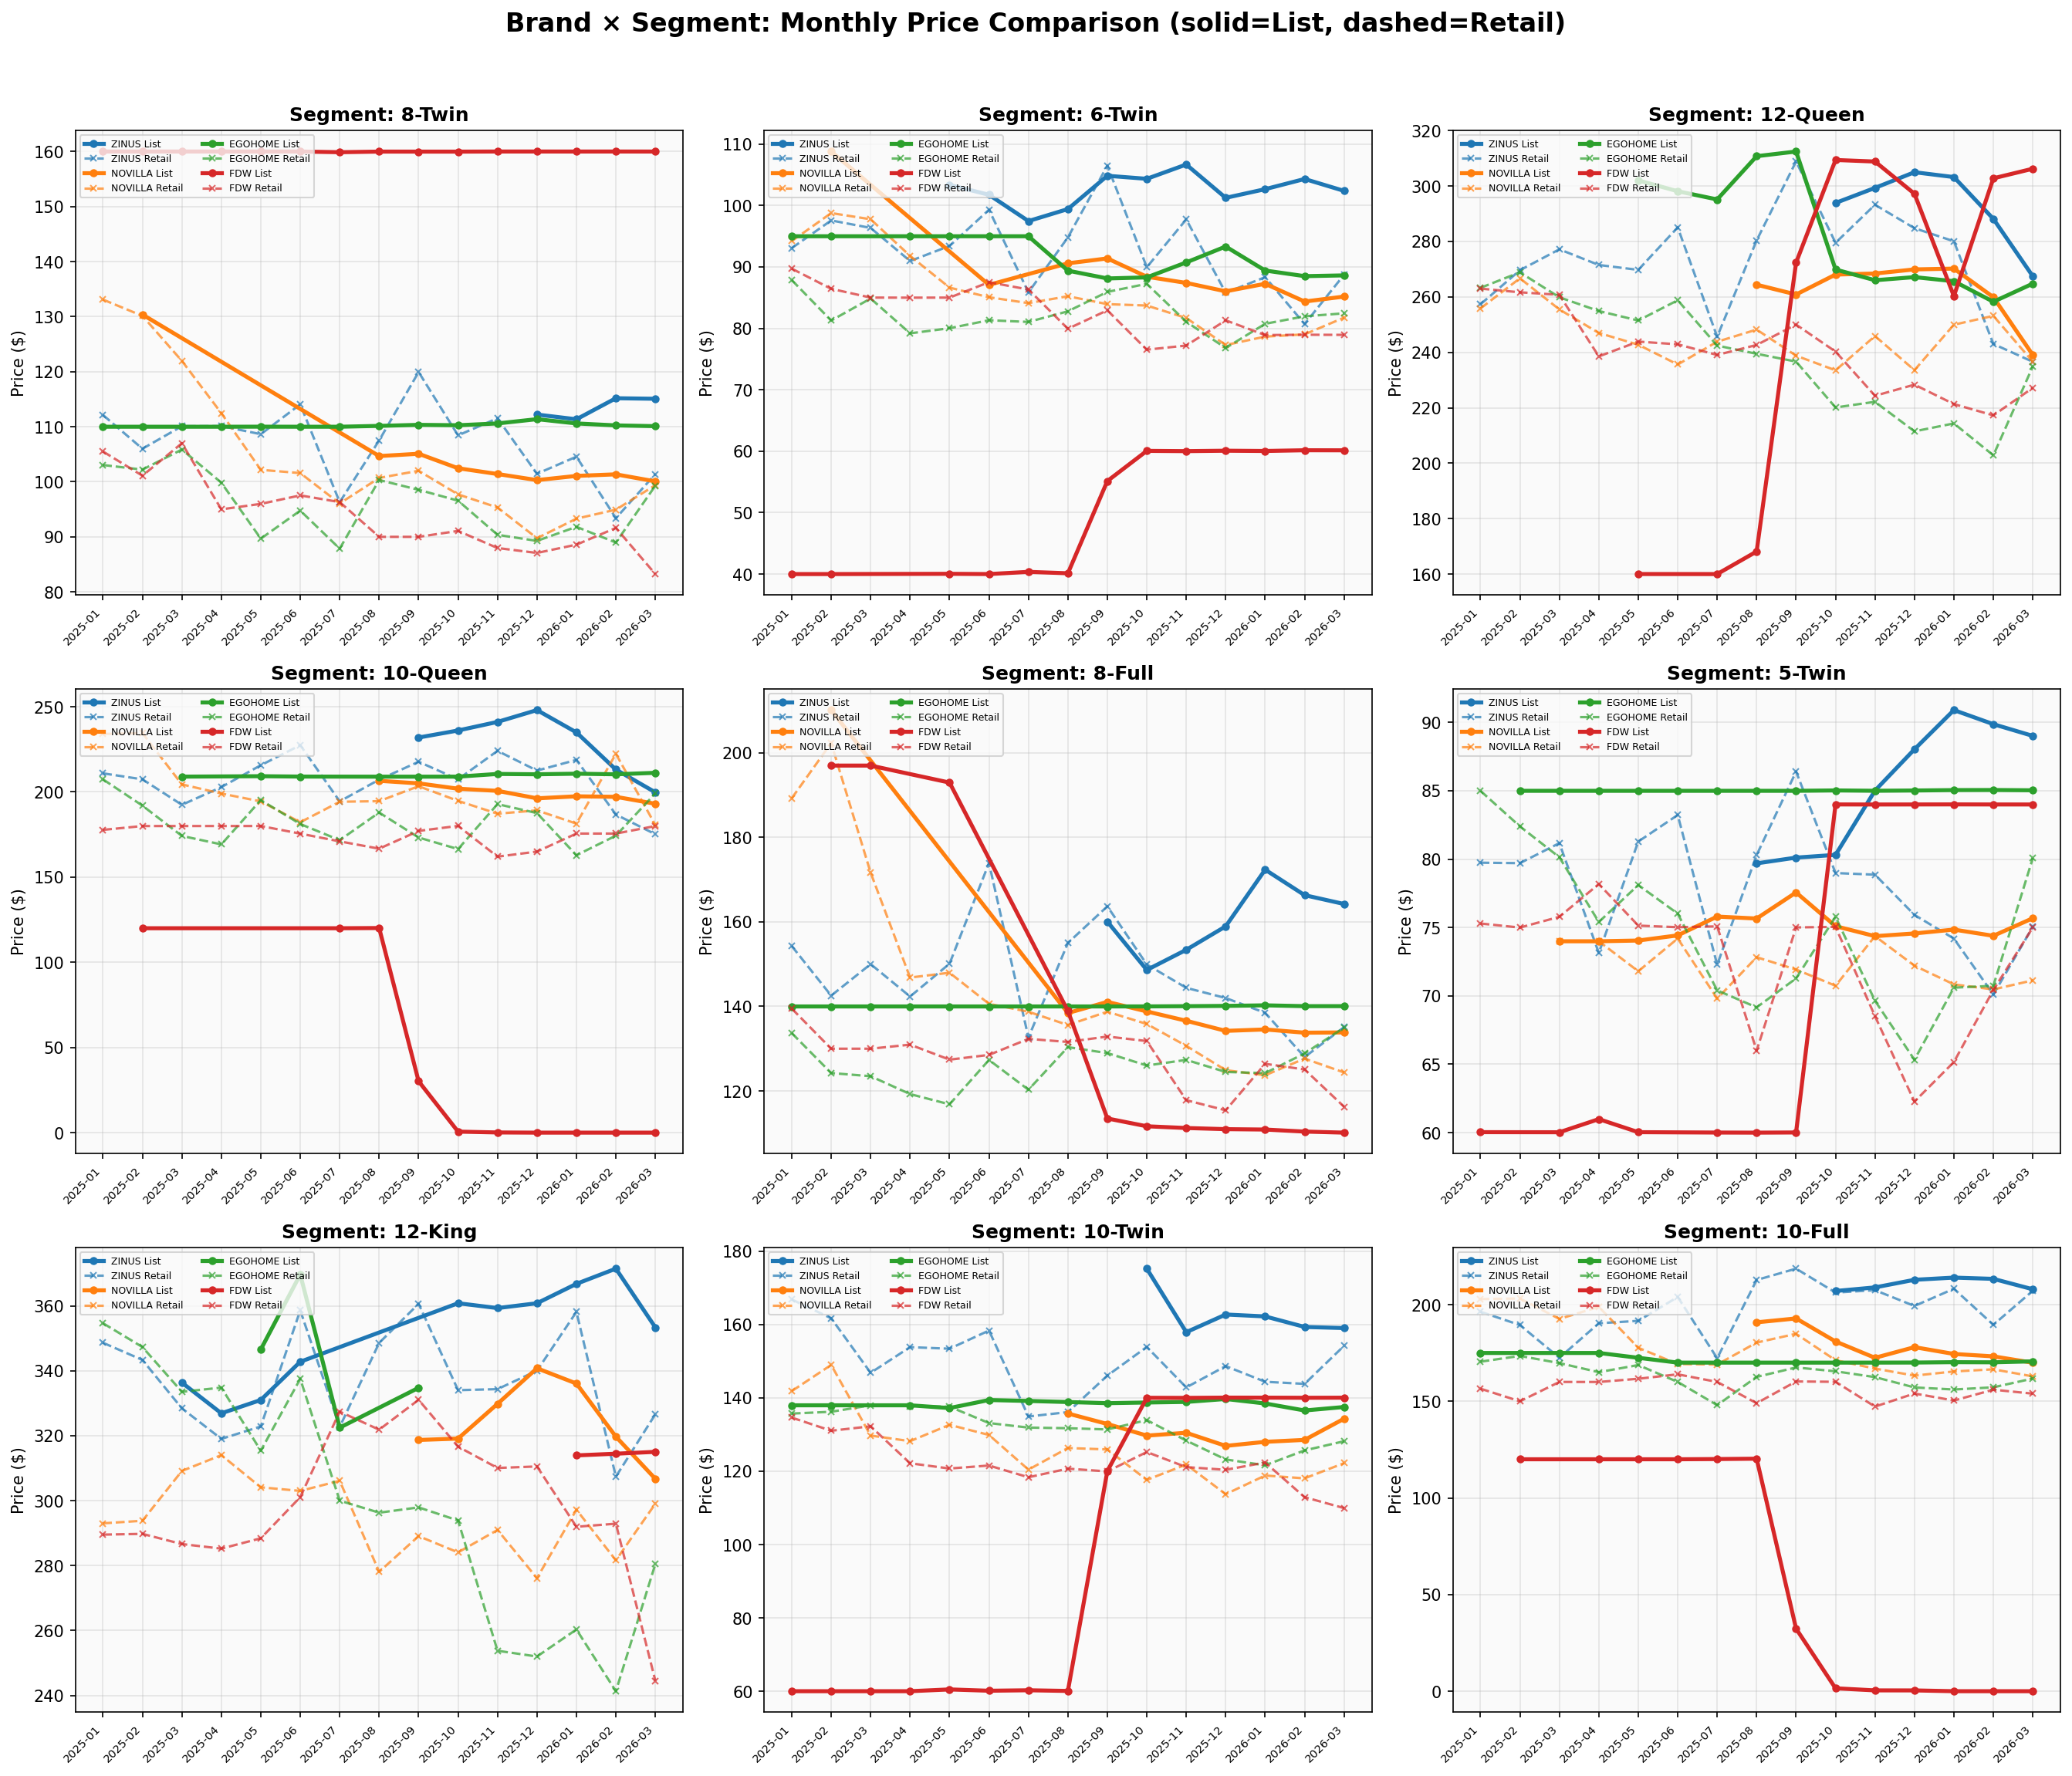

In [57]:
# ── 대상 데이터 필터 ──
brands = ['ZINUS', 'NOVILLA', 'EGOHOME', 'FDW']
brand_colors = {'ZINUS': '#1f77b4', 'NOVILLA': '#ff7f0e', 'EGOHOME': '#2ca02c', 'FDW': '#d62728'}

bdf = df[df['brand'].isin(brands)].copy()
bdf['segment'] = bdf['inch'].astype(str) + '-' + bdf['size'].astype(str)

# ── 주요 세그먼트 선정 (총 유닛 기준 Top 9) ──
top_segments = bdf.groupby('segment')['units'].sum().nlargest(9).index.tolist()

all_months = sorted(bdf['yr_month'].unique())

# ── 세그먼트별 차트 (3×3 그리드) ──
n_cols = 3
n_rows = (len(top_segments) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Brand × Segment: Monthly Price Comparison (solid=List, dashed=Retail)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, seg in enumerate(top_segments):
    ax = axes[idx // n_cols, idx % n_cols]
    sdf = bdf[bdf['segment'] == seg]

    for brand in brands:
        bsdf = sdf[sdf['brand'] == brand]
        if len(bsdf) == 0:
            continue
        color = brand_colors[brand]

        # 월별 유닛 가중평균 — List Price
        monthly_list = (bsdf.groupby('yr_month')
                        .apply(lambda g: np.average(g['avg_list_price'], weights=g['units'])
                               if g['units'].sum() > 0 and g['avg_list_price'].notna().any()
                               else np.nan)
                        .dropna())
        if len(monthly_list) > 0:
            months = sorted(monthly_list.index)
            x_pos = [all_months.index(m) for m in months]
            ax.plot(x_pos, [monthly_list[m] for m in months],
                    marker='o', markersize=4, linewidth=2.5,
                    color=color, label=f'{brand} List')

        # 월별 유닛 가중평균 — Retail Price
        monthly_retail = (bsdf.groupby('yr_month')
                          .apply(lambda g: np.average(g['avg_retail_price'], weights=g['units'])
                                 if g['units'].sum() > 0 else np.nan)
                          .dropna())
        if len(monthly_retail) > 0:
            months = sorted(monthly_retail.index)
            x_pos = [all_months.index(m) for m in months]
            ax.plot(x_pos, [monthly_retail[m] for m in months],
                    marker='x', markersize=4, linewidth=1.5, linestyle='--',
                    color=color, alpha=0.7, label=f'{brand} Retail')

    ax.set_xticks(range(len(all_months)))
    ax.set_xticklabels(all_months, fontsize=7, rotation=45, ha='right')
    ax.set_title(f'Segment: {seg}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=6, loc='upper left', ncol=2)

# 빈 subplot 숨기기
for idx in range(len(top_segments), n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

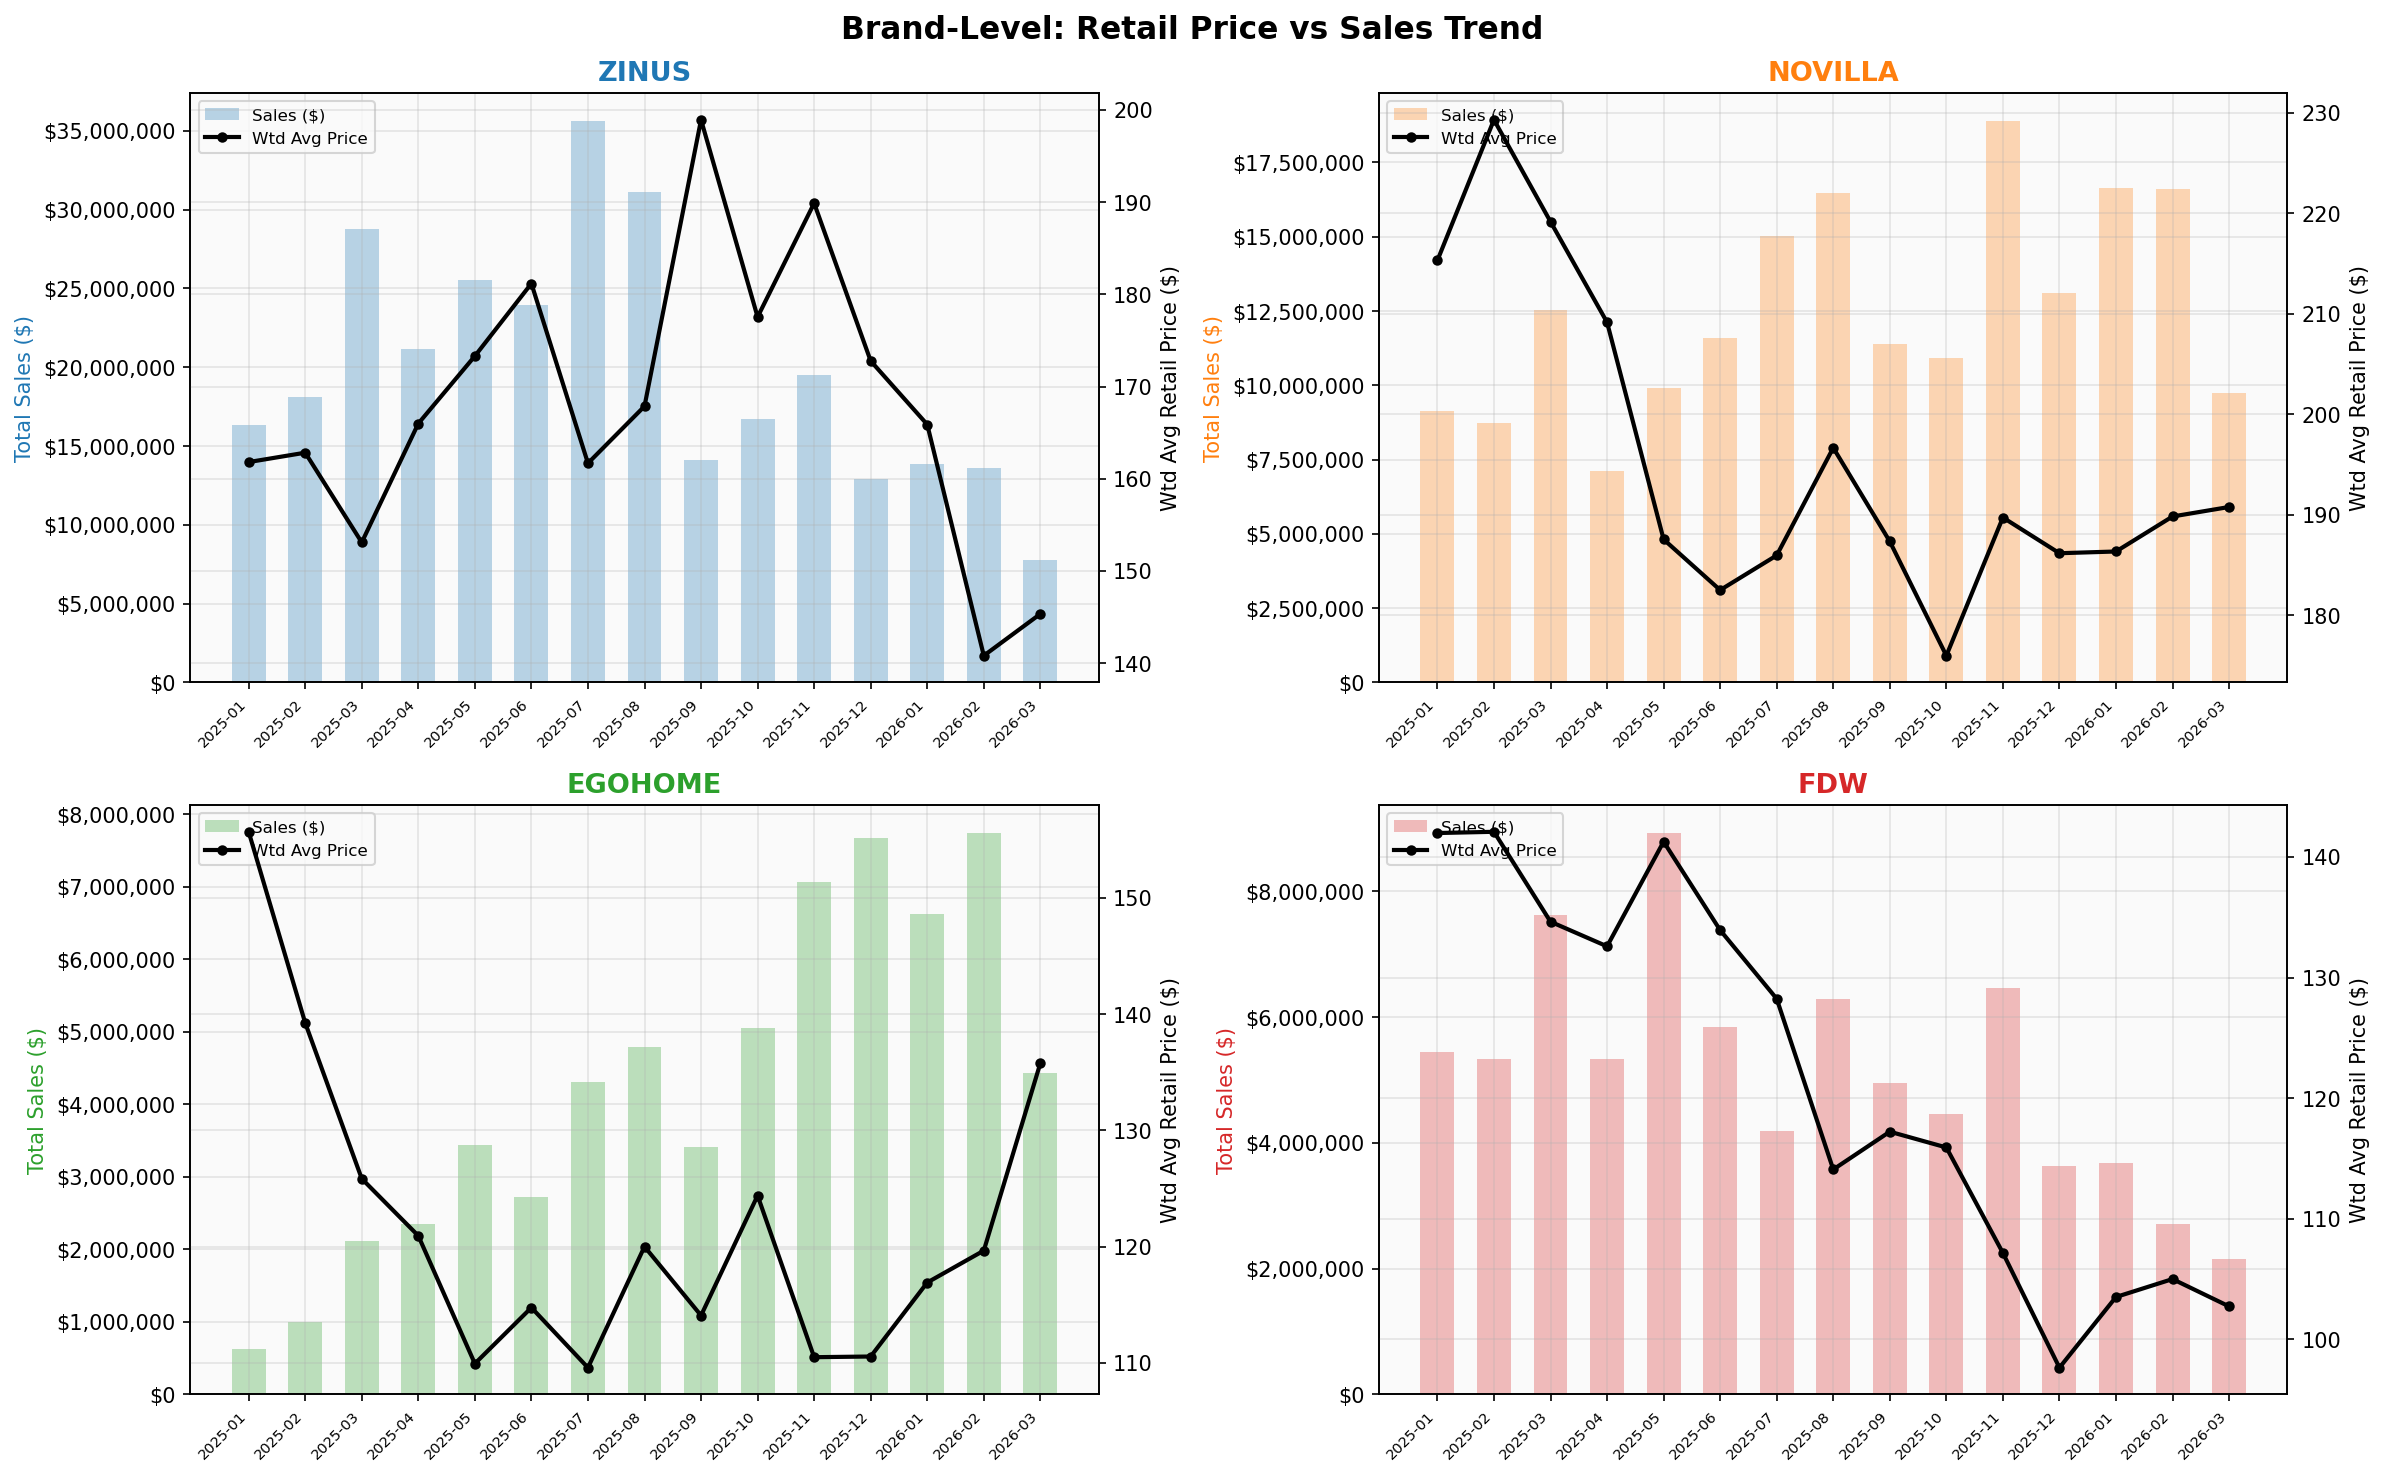


Monthly Change: Price vs Sales (MoM %)

▶ ZINUS
yr_month  wavg_price  price_chg  total_sales  sales_chg  total_units  units_chg
 2025-01       161.8        NaN   16356380.9        NaN       102480       <NA>
 2025-02       162.8        0.6   18081139.3       10.5       115926       13.1
 2025-03       153.1       -6.0   28782390.7       59.2       194854       68.1
 2025-04       166.0        8.4   21141871.6      -26.5       128326      -34.1
 2025-05       173.3        4.4   25552941.2       20.9       148400       15.6
 2025-06       181.2        4.5   23953718.4       -6.3       133011      -10.4
 2025-07       161.7      -10.8   35618022.2       48.7       235869       77.3
 2025-08       167.9        3.8   31089944.7      -12.7       191118      -19.0
 2025-09       198.9       18.5   14137695.6      -54.5        71770      -62.4
 2025-10       177.5      -10.7   16704874.7       18.2       100183       39.6
 2025-11       189.9        6.9   19513759.2       16.8       110491   

In [59]:
# ── 대상 데이터 필터 ──
brands = ['ZINUS', 'NOVILLA', 'EGOHOME', 'FDW']
brand_colors = {'ZINUS': '#1f77b4', 'NOVILLA': '#ff7f0e', 'EGOHOME': '#2ca02c', 'FDW': '#d62728'}

bdf = df[df['brand'].isin(brands)].copy()

# ── 브랜드별 월별 집계 ──
monthly = (bdf.groupby(['brand', 'yr_month'])
           .agg(
               wavg_price=('avg_retail_price', lambda x: np.average(x, weights=bdf.loc[x.index, 'units']) if bdf.loc[x.index, 'units'].sum() > 0 else np.nan),
               total_sales=('sales', 'sum'),
               total_units=('units', 'sum'),
           )
           .reset_index())

all_months = sorted(monthly['yr_month'].unique())

# ── 브랜드별 Dual Axis 차트 (Price 선 + Sales 막대) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Brand-Level: Retail Price vs Sales Trend', fontsize=15, fontweight='bold')

for ax, brand in zip(axes.flat, brands):
    bm = monthly[monthly['brand'] == brand].sort_values('yr_month')
    x_pos = [all_months.index(m) for m in bm['yr_month']]
    color = brand_colors[brand]

    # 막대: Sales
    ax.bar(x_pos, bm['total_sales'], width=0.6, alpha=0.3, color=color, label='Sales ($)')
    ax.set_ylabel('Total Sales ($)', color=color)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

    # 선: Price (secondary axis)
    ax2 = ax.twinx()
    ax2.plot(x_pos, bm['wavg_price'], color='black', marker='o', markersize=4,
             linewidth=2, label='Wtd Avg Price')
    ax2.set_ylabel('Wtd Avg Retail Price ($)')

    ax.set_xticks(range(len(all_months)))
    ax.set_xticklabels(all_months, fontsize=7, rotation=45, ha='right')
    ax.set_title(brand, color=color, fontsize=13, fontweight='bold')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# ── MoM 변화율 테이블 ──
print("\n" + "=" * 80)
print("Monthly Change: Price vs Sales (MoM %)")
print("=" * 80)

for brand in brands:
    bm = monthly[monthly['brand'] == brand].sort_values('yr_month').reset_index(drop=True)
    bm['price_chg'] = bm['wavg_price'].pct_change() * 100
    bm['sales_chg'] = bm['total_sales'].pct_change() * 100
    bm['units_chg'] = bm['total_units'].pct_change() * 100

    print(f"\n▶ {brand}")
    print(bm[['yr_month', 'wavg_price', 'price_chg', 'total_sales', 'sales_chg', 'total_units', 'units_chg']]
          .round(1).to_string(index=False))

# ── 상관계수 요약 ──
print("\n" + "=" * 80)
print("Correlation: Price Change vs Sales Change (MoM)")
print("=" * 80)

for brand in brands:
    bm = monthly[monthly['brand'] == brand].sort_values('yr_month').reset_index(drop=True)
    bm['price_chg'] = bm['wavg_price'].pct_change()
    bm['sales_chg'] = bm['total_sales'].pct_change()
    bm['units_chg'] = bm['total_units'].pct_change()

    corr_sales = bm[['price_chg', 'sales_chg']].dropna().corr().iloc[0, 1]
    corr_units = bm[['price_chg', 'units_chg']].dropna().corr().iloc[0, 1]
    print(f"  {brand:10s} | Price↔Sales: {corr_sales:+.3f} | Price↔Units: {corr_units:+.3f}")

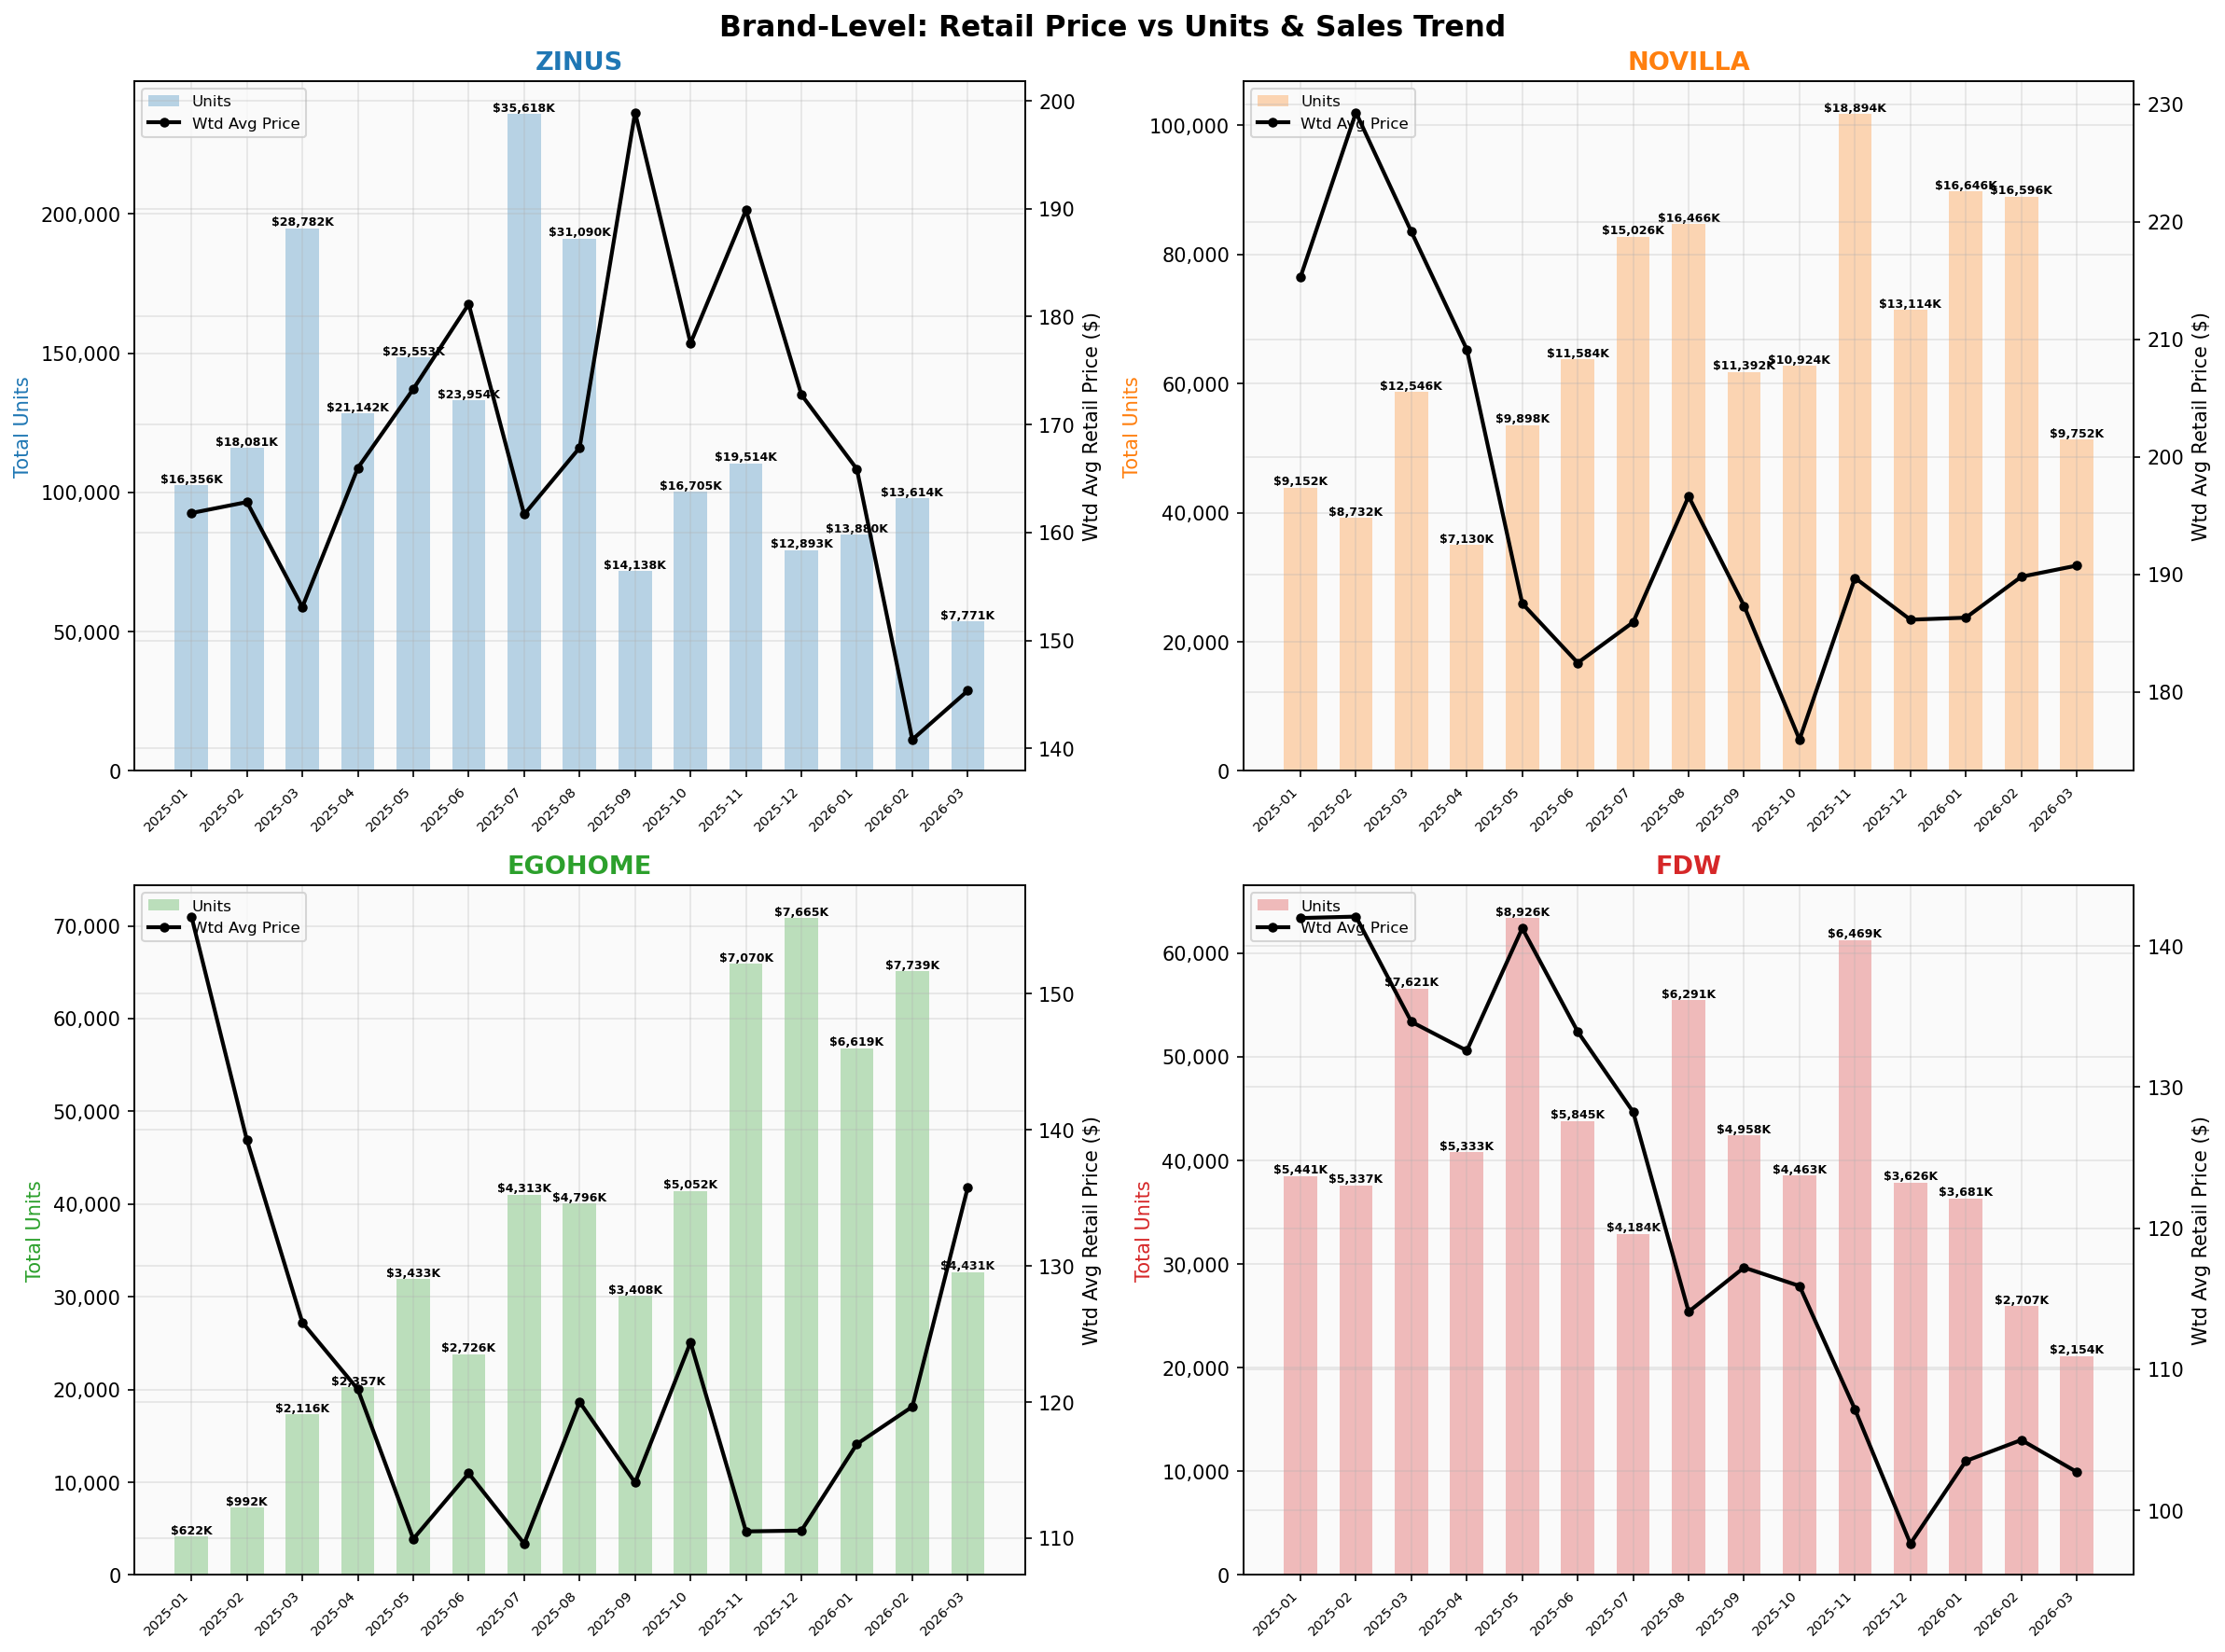

In [63]:
# ── 대상 데이터 필터 ──
brands = ['ZINUS', 'NOVILLA', 'EGOHOME', 'FDW']
brand_colors = {'ZINUS': '#1f77b4', 'NOVILLA': '#ff7f0e', 'EGOHOME': '#2ca02c', 'FDW': '#d62728'}
bdf = df[df['brand'].isin(brands)].copy()

# ── 브랜드별 월별 집계 ──
monthly = (bdf.groupby(['brand', 'yr_month'])
           .agg(
               wavg_price=('avg_retail_price', lambda x: np.average(x, weights=bdf.loc[x.index, 'units']) if bdf.loc[x.index, 'units'].sum() > 0 else np.nan),
               total_sales=('sales', 'sum'),
               total_units=('units', 'sum'),
           )
           .reset_index())
all_months = sorted(monthly['yr_month'].unique())

# ── 브랜드별 Dual Axis 차트 (Units 막대 + Price 선 + Sales 텍스트) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Brand-Level: Retail Price vs Units & Sales Trend', fontsize=15, fontweight='bold')

for ax, brand in zip(axes.flat, brands):
    bm = monthly[monthly['brand'] == brand].sort_values('yr_month')
    x_pos = [all_months.index(m) for m in bm['yr_month']]
    color = brand_colors[brand]

    # 막대: Units (왼쪽 y축)
    ax.bar(x_pos, bm['total_units'], width=0.6, alpha=0.3, color=color, label='Units')
    ax.set_ylabel('Total Units', color=color)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    # 막대 위에 Sales 텍스트 (천달러 단위)
    for xp, units, sales in zip(x_pos, bm['total_units'], bm['total_sales']):
        ax.text(xp, units, f'${sales/1000:,.0f}K', ha='center', va='bottom',
                fontsize=6, fontweight='bold', color='black')

    # 선: Price (오른쪽 y축)
    ax2 = ax.twinx()
    ax2.plot(x_pos, bm['wavg_price'], color='black', marker='o', markersize=4,
             linewidth=2, label='Wtd Avg Price')
    ax2.set_ylabel('Wtd Avg Retail Price ($)')

    ax.set_xticks(range(len(all_months)))
    ax.set_xticklabels(all_months, fontsize=7, rotation=45, ha='right')
    ax.set_title(brand, color=color, fontsize=13, fontweight='bold')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

### 2025년 거만

In [43]:
plot_zns_df = df_2025[df_2025['brand']=='ZINUS'].copy()
print(plot_zns_df)

       final_inch final_size  brand    bsr_date        asin parent_asin  \
27248        10.0       Full  ZINUS  2025-11-20  B0CKYYT6VY  B0DNSJJBX6   
27249        10.0       Full  ZINUS  2025-01-21  B0CKYYT6VY  B0DNSJJBX6   
27250        10.0       Full  ZINUS  2025-11-17  B0CKYYT6VY  B0DNSJJBX6   
27251        10.0       Full  ZINUS  2025-01-23  B0CKYYT6VY  B0DNSJJBX6   
27252        10.0       Full  ZINUS  2025-11-19  B0CKYYT6VY  B0DNSJJBX6   
...           ...        ...    ...         ...         ...         ...   
93144         8.0       Twin  ZINUS  2025-06-30  B0CSJTKX7K  B0F198BNN7   
93145         8.0       Twin  ZINUS  2025-04-07  B0CSJTKX7K  B0F198BNN7   
93146         8.0       Twin  ZINUS  2025-09-20  B0CSJTKX7K  B0F198BNN7   
93147         8.0       Twin  ZINUS  2025-06-25  B0CSJTKX7K  B0F198BNN7   
93148         8.0       Twin  ZINUS  2025-03-20  B0CSJTKX7K  B0F198BNN7   

      meta_brand      type  size style  ... package_weight package_width  \
27248      Zinus  MATTR

## 기타 테스트